# DAIC-WOZ Audio Processing Pipeline
**Goal:** Extract **participant-only speech** from raw interview audio using transcript timestamps, then convert to log-mel spectrograms for PHQ-8 depression prediction.

**Why separate speakers?**  
The `*_AUDIO.wav` file is recorded from a head-mounted microphone on the participant, but contains bleed-over from Ellie (the virtual interviewer). Including Ellie's voice adds irrelevant acoustic signal and can introduce bias — models trained on mixed audio learn shortcuts from interviewer questions rather than genuine depression markers in the participant's speech. The `*_TRANSCRIPT.csv` provides exact `start_time` / `stop_time` / `speaker` timestamps to surgically extract only participant turns.

**Pipeline per participant:**
1. Load train/dev/test label CSVs upfront to build a split lookup
2. Extract `*_AUDIO.wav` + `*_TRANSCRIPT.csv` from ZIP
3. Parse transcript → keep only rows where `speaker == 'Participant'`
4. Slice and concatenate participant-only audio segments
5. Resample concatenated audio to 16 kHz
6. Segment into fixed-length windows (8 s, 50% overlap)
7. Convert each window to a log-mel spectrogram → save directly into `spectrograms/train`, `spectrograms/dev`, or `spectrograms/test`
8. Attach PHQ-8 labels into metadata

**Known dataset issues handled:**
- **P373**: Confederate enters room at ~5:52–7:00 to fix a technical issue. Interruption window is explicitly masked out before turn extraction.
- **P444**: Participant's phone rings at ~4:46–6:27, confederate enters to help. Interruption window is explicitly masked out before turn extraction.
- **P451, P458, P480**: Missing Ellie (virtual human) transcript entries — participant turns are still present in the transcript and are processed normally.
- **Participant 409**: PHQ-8 label error (score=10 but original binary=0) — corrected during label attachment.

## Install Dependencies

In [25]:
!pip install librosa soundfile tqdm pandas numpy --quiet

# print success message
print("All packages installed successfully!")

All packages installed successfully!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports & Configuration

In [26]:
import zipfile
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


In [ ]:
# Folder containing ALL participant ZIPs (train + dev + test)
DATASET_DIR = Path('./dataset')

# Output locations
OUTPUT_DIR = Path('./processed')
SPEC_DIR = OUTPUT_DIR / 'spectrograms'     # parent; subfolders train/dev/test created after split lookup
EXTRACT_DIR = OUTPUT_DIR / 'extracted_audio'  # temporary extraction (cleaned up per participant)

# Audio parameters 
TARGET_SR = 16_000  # resample target in Hz (DAIC-WOZ native is already 16 kHz)
WINDOW_SEC = 8.0    # sliding window length in seconds
HOP_SEC = 4.0       # hop between windows → 50% overlap

# Minimum participant speech required to produce at least one window.
# Participants with less total speech than this are skipped. (highly unlikely)
MIN_SPEECH_SEC = WINDOW_SEC

# Mel-spectrogram parameters
N_FFT = 1024      # FFT window size
HOP_LENGTH = 160  # STFT hop  — 10 ms @ 16 kHz
WIN_LENGTH = 400  # STFT window — 25 ms @ 16 kHz
N_MELS = 128      # mel filterbanks
FMIN = 50         # lowest mel frequency (Hz)
FMAX = 8_000      # highest mel frequency — Nyquist for 16 kHz

# Known dataset issues
# Exact interruption windows (in seconds) to exclude from P373 and P444.
# A participant turn is dropped if it overlaps with these ranges.
# P373: confederate enters room to fix a technical issue (~5:52–7:00)
# P444: participant's phone rings, confederate enters to help (~4:46–6:27)
INTERRUPTION_RANGES = {
    373: (5*60 + 52, 7*60 +  0),   # 352s – 420s
    444: (4*60 + 46, 6*60 + 27),   # 286s – 387s
}

# P451, P458, P480: missing Ellie transcript entries only —
# participant turns ARE present and are processed normally (no special handling needed).

# PHQ-8 binary label correction applied during label attachment (Section 6)
LABEL_CORRECTIONS = {409: {'binary_label': 1}}   # score=10 but original binary=0

# Depression threshold (label attachment only)
# PHQ-8 score ≥ 10 is labeled as "depressed" (binary label = 1)
# otherwise "not depressed" (binary label = 0).
PHQ8_THRESHOLD = 10

# Create directories (split subfolders created after label CSVs are loaded)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f'  Dataset dir : {DATASET_DIR.resolve()}')
print(f'  Output dir  : {OUTPUT_DIR.resolve()}')
print(f'  Window      : {WINDOW_SEC}s  |  Hop: {HOP_SEC}s  →  {HOP_SEC/WINDOW_SEC*100:.0f}% overlap')
print(f'  Sample rate : {TARGET_SR} Hz  |  Mels: {N_MELS}')

Configuration loaded.
  Dataset dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\dataset
  Output dir  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed
  Window      : 8.0s  |  Hop: 4.0s  →  50% overlap
  Sample rate : 16000 Hz  |  Mels: 128


## Discover All Participant ZIPs

In [28]:
zip_files = sorted(DATASET_DIR.glob('*.zip'))
if not zip_files:
    raise FileNotFoundError(
        f'No ZIP files found in {DATASET_DIR.resolve()}. Update DATASET_DIR above.'
    )

valid_zips = []
for z in zip_files:
    try:
        pid = int(z.stem.split('_')[0])
        valid_zips.append((pid, z))
    except ValueError:
        print(f'[SKIP] Cannot parse participant ID from {z.name}')

valid_zips.sort()
participant_ids = [pid for pid, _ in valid_zips]

print(f'\nFound {len(valid_zips)} participant ZIPs')
print(f'ID range : {participant_ids[0]} – {participant_ids[-1]}')

print(f'\n[WARNING] Interruption masking for : {list(INTERRUPTION_RANGES.keys())}')

[SKIP] Cannot parse participant ID from documents.zip
[SKIP] Cannot parse participant ID from util.zip

Found 189 participant ZIPs
ID range : 300 – 492

[WARNING] Interruption masking for : [373, 444]


## Core Processing Functions

In [ ]:
def extract_files_from_zip(zip_path, extract_to):
    """
    Extract *_AUDIO.wav and *_TRANSCRIPT.csv from a participant ZIP.
    Returns (wav_path, transcript_path). Either may be None if not found.
    """
    wav_path, transcript_path = None, None
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = zf.namelist()
        for name in names:
            if name.endswith('_AUDIO.wav'):
                zf.extract(name, extract_to)
                wav_path = extract_to / name
            elif name.endswith('_TRANSCRIPT.csv'):
                zf.extract(name, extract_to)
                transcript_path = extract_to / name
    return wav_path, transcript_path

def load_participant_turns(transcript_path, pid):
    """
    Parse the DAIC-WOZ transcript CSV and return a DataFrame of
    participant-only turns with columns: start_time, stop_time.

    The transcript is tab-separated with columns:
        start_time  stop_time  speaker  value
    Speaker values are 'Ellie' and 'Participant'.
    Rows where value == 'scrubbed_entry' are silence-zeroed in the audio — skip them.

    For P373 and P444, any turn that overlaps with the documented interruption
    window is removed so confederate noise is not included.
    """
    try:
        df = pd.read_csv(transcript_path, sep='\t')
    except Exception:
        df = pd.read_csv(transcript_path, sep=r'\s+', engine='python')

    df.columns = df.columns.str.strip().str.lower()

    # Keep only participant turns, exclude scrubbed (zeroed-out) entries
    mask = (
        (df['speaker'].str.strip().str.lower() == 'participant') &
        (df['value'].astype(str).str.strip().str.lower() != 'scrubbed_entry')
    )
    turns = df.loc[mask, ['start_time', 'stop_time']].copy()
    turns = turns.dropna()
    turns['start_time'] = turns['start_time'].astype(float)
    turns['stop_time'] = turns['stop_time'].astype(float)
    turns = turns[turns['stop_time'] > turns['start_time']].reset_index(drop=True)

    # Mask out documented interruption windows for P373 and P444
    if pid in INTERRUPTION_RANGES:
        int_start, int_end = INTERRUPTION_RANGES[pid]
        # Drop any turn whose time range overlaps with the interruption window.
        # A turn overlaps if it starts before int_end AND ends after int_start.
        overlaps = (turns['start_time'] < int_end) & (turns['stop_time'] > int_start)
        n_removed = overlaps.sum()
        turns = turns[~overlaps].reset_index(drop=True)
        print(f'  [P{pid}] Interruption masked ({int_start:.0f}s–{int_end:.0f}s): '
              f'{n_removed} turn(s) removed.')

    return turns

def extract_participant_audio(waveform, sr, turns):
    """
    Slice participant turns from the waveform and concatenate into one array.
    Returns a 1-D numpy array of concatenated participant speech.
    """
    slices = []
    audio_duration = len(waveform) / sr

    for _, row in turns.iterrows():
        start_sample = int(row['start_time'] * sr)
        stop_sample = int(row['stop_time']  * sr)

        # Guard against timestamps that exceed audio length
        stop_sample = min(stop_sample, len(waveform))
        if stop_sample <= start_sample:
            continue

        slices.append(waveform[start_sample:stop_sample])

    if not slices:
        return np.array([], dtype=np.float32)

    return np.concatenate(slices).astype(np.float32)

def segment_waveform(waveform, sr, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    """
    Split waveform into fixed-length overlapping windows.
    Trailing partial window is discarded.
    """
    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)
    segments, start = [], 0
    while start + window_samples <= len(waveform):
        segments.append(waveform[start : start + window_samples])
        start += hop_samples
    return segments

def waveform_to_logmel(segment, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX):
    """
    Convert a waveform segment to a standardised log-mel spectrogram.
    Returns array of shape (N_MELS, T), dtype float32, with mean=0 and std=1.
    """
    mel = librosa.feature.melspectrogram(
        y=segment, sr=sr, n_fft=n_fft, hop_length=hop_length,
        win_length=win_length, n_mels=n_mels, fmin=fmin, fmax=fmax
    )
    log_mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    # Per-segment standardisation: zero mean, unit variance
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)
    return log_mel

print('Processing functions defined!')

Processing functions defined!


## Visualise a Single Example (Sanity Check)
Shows the **full** waveform vs the **participant-only** waveform, plus the resulting log-mel spectrogram.

Visualising participant 300 from 300_P.zip ...
  Transcript turns  : 87 participant turns
  Full duration     : 648.5s
  Participant speech: 155.8s  (24.0% of total)
  Ellie / other     : 492.7s removed
  Windows produced  : 37


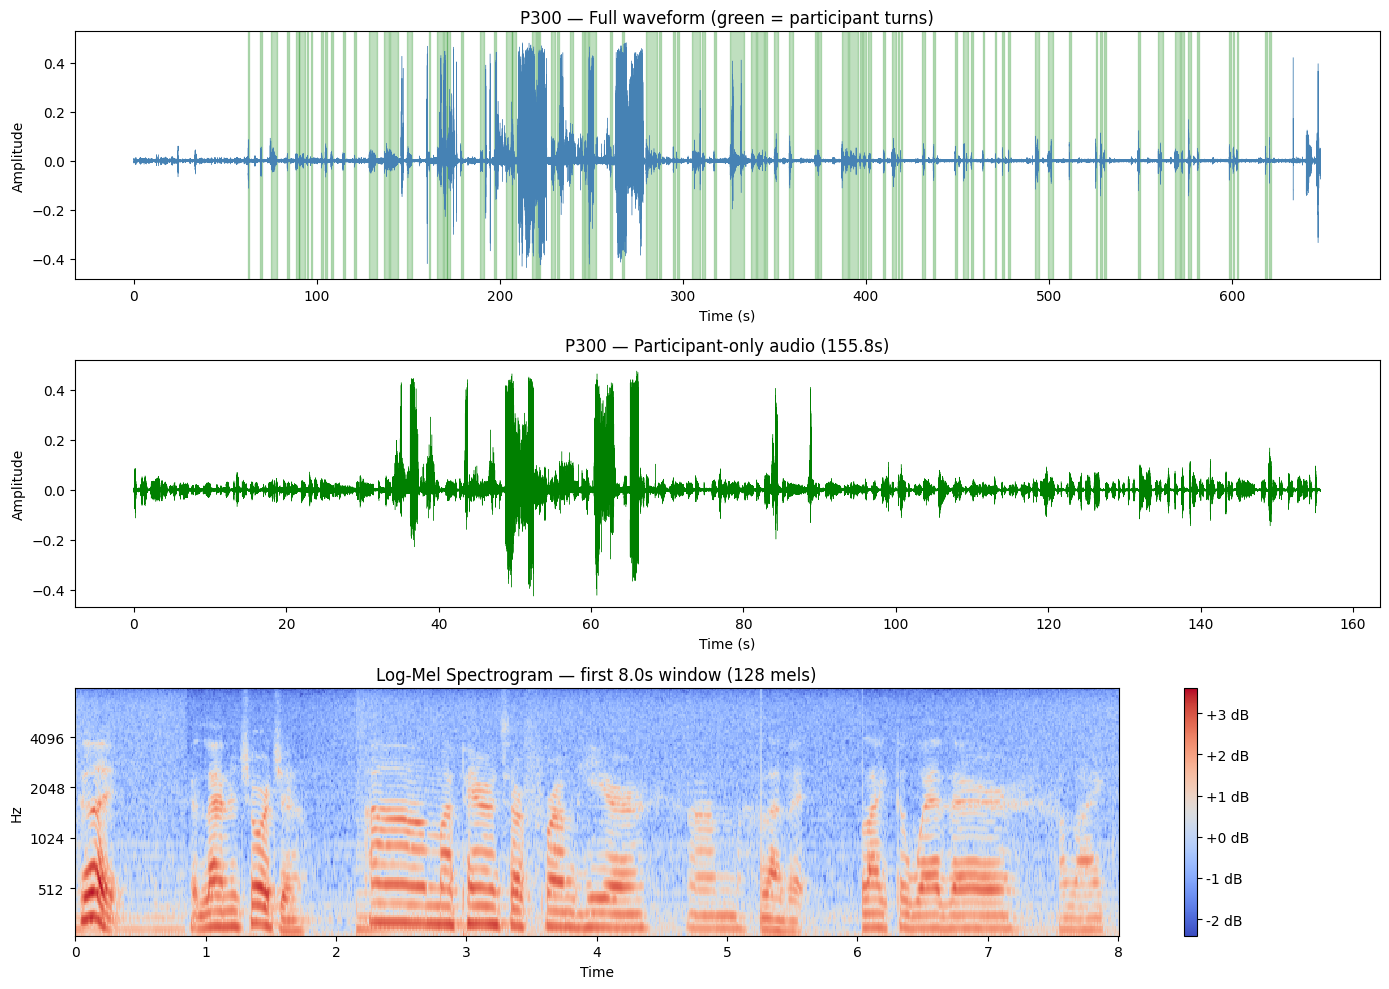

Sanity-check passed.


In [ ]:
sample_pid, sample_zip = valid_zips[0]
print(f'Visualising participant {sample_pid} from {sample_zip.name} ...')

wav_path, transcript_path = extract_files_from_zip(sample_zip, EXTRACT_DIR)

if wav_path is None:
    print('[ERROR] No audio file found in ZIP.')
elif transcript_path is None:
    print('[ERROR] No transcript file found in ZIP.')
else:
    # Load full waveform
    full_waveform, sr = librosa.load(wav_path, sr=TARGET_SR, mono=True)

    # Load participant turns and extract speech
    turns = load_participant_turns(transcript_path, sample_pid)
    participant_audio = extract_participant_audio(full_waveform, sr, turns)

    full_dur = len(full_waveform) / sr
    participant_dur = len(participant_audio) / sr
    speech_ratio = participant_dur / full_dur * 100

    print(f'  Transcript turns  : {len(turns)} participant turns')
    print(f'  Full duration     : {full_dur:.1f}s')
    print(f'  Participant speech: {participant_dur:.1f}s  ({speech_ratio:.1f}% of total)')
    print(f'  Ellie / other     : {full_dur - participant_dur:.1f}s removed')

    # Spectrogram of first segment
    segments = segment_waveform(participant_audio, sr)
    print(f'  Windows produced  : {len(segments)}')

    log_mel = waveform_to_logmel(segments[0])

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Full waveform
    t_full = np.linspace(0, full_dur, len(full_waveform))
    axes[0].plot(t_full, full_waveform, lw=0.3, color='steelblue')
    for _, row in turns.iterrows():
        axes[0].axvspan(row['start_time'], row['stop_time'], alpha=0.25, color='green')
    axes[0].set_title(f'P{sample_pid} — Full waveform (green = participant turns)')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')

    # Participant-only concatenated waveform
    t_part = np.linspace(0, participant_dur, len(participant_audio))
    axes[1].plot(t_part, participant_audio, lw=0.3, color='green')
    axes[1].set_title(f'P{sample_pid} — Participant-only audio ({participant_dur:.1f}s)')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude')

    # Log-mel spectrogram of first window
    img = librosa.display.specshow(
        log_mel, sr=sr, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX, ax=axes[2]
    )
    axes[2].set_title(f'Log-Mel Spectrogram — first {WINDOW_SEC}s window ({N_MELS} mels)')
    fig.colorbar(img, ax=axes[2], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

    # Cleanup
    wav_path.unlink(missing_ok=True)
    transcript_path.unlink(missing_ok=True)
    print('Sanity-check passed.')

## Load Labels & Build Split Lookup

Labels are loaded **before** processing so each participant's split is known at save time,
allowing spectrograms to be written directly into `spectrograms/train`, `spectrograms/dev`, or `spectrograms/test`.

The known label error for participant 409 (PHQ-8=10 but original binary=0) is corrected automatically.

In [ ]:
# Point these at your label CSVs
TRAIN_LABELS_CSV = Path('./dataset/train_split_Depression_AVEC2017.csv')
DEV_LABELS_CSV = Path('./dataset/dev_split_Depression_AVEC2017.csv')
TEST_LABELS_CSV = Path('./dataset/full_test_split.csv')

def load_label_csv(csv_path, split_name):
    if csv_path is None or not csv_path.exists():
        print(f'  [{split_name}] Not found at {csv_path} — skipping.')
        return pd.DataFrame(columns=['Participant_ID', 'PHQ_Score', 'split'])
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    col_map = {}
    for col in df.columns:
        lc = col.lower()
        if 'participant' in lc:            col_map[col] = 'Participant_ID'
        if 'phq' in lc and 'score' in lc: col_map[col] = 'PHQ_Score'
    df.rename(columns=col_map, inplace=True)
    df['split'] = split_name
    print(f'  [{split_name}] Loaded {len(df)} participants from {csv_path.name}')
    return df[['Participant_ID', 'PHQ_Score', 'split']]

labels_df = pd.concat([
    load_label_csv(TRAIN_LABELS_CSV, 'train'),
    load_label_csv(DEV_LABELS_CSV,   'dev'),
    load_label_csv(TEST_LABELS_CSV,  'test'),
], ignore_index=True)

labels_df['Participant_ID'] = labels_df['Participant_ID'].astype(int)
labels_df['binary_label']   = (labels_df['PHQ_Score'] >= PHQ8_THRESHOLD).astype('Int64')

# Apply known label corrections
for pid, corrections in LABEL_CORRECTIONS.items():
    mask = labels_df['Participant_ID'] == pid
    if mask.any():
        for col, val in corrections.items():
            labels_df.loc[mask, col] = val
        print(f'  [CORRECTION] Applied label fix for P{pid}: {corrections}')

# Build lookup: pid -> {phq_score, binary_label, split}
label_lookup = {
    int(r['Participant_ID']): {
        'phq_score':    float(r['PHQ_Score']) if pd.notna(r.get('PHQ_Score')) else None,
        'binary_label': int(r['binary_label']) if pd.notna(r.get('binary_label')) else None,
        'split':        r['split'],
    }
    for _, r in labels_df.iterrows()
}

# Create split subfolders now that we know which splits exist
for split_name in labels_df['split'].unique():
    (SPEC_DIR / split_name).mkdir(parents=True, exist_ok=True)

print(f'\nLabels loaded: {len(label_lookup)} participants')
print(f'Split counts  : {labels_df["split"].value_counts().to_dict()}')
if 'PHQ_Score' in labels_df.columns:
    print(f'PHQ-8 summary :\n{labels_df["PHQ_Score"].dropna().describe().round(2)}')
    print(f'High-risk (>={PHQ8_THRESHOLD}): {labels_df["binary_label"].sum()} / {labels_df["binary_label"].count()}')
print(f'\nSpectrogram subfolders created:')
for p in sorted(SPEC_DIR.iterdir()):
    print(f'  {p}')

  [train] Loaded 107 participants from train_split_Depression_AVEC2017.csv
  [dev] Loaded 35 participants from dev_split_Depression_AVEC2017.csv
  [test] Loaded 47 participants from full_test_split.csv
  [CORRECTION] Applied label fix for P409: {'binary_label': 1}

Labels loaded: 189 participants
Split counts  : {'train': 107, 'test': 47, 'dev': 35}
PHQ-8 summary :
count    189.00
mean       6.75
std        5.92
min        0.00
25%        2.00
50%        5.00
75%       10.00
max       23.00
Name: PHQ_Score, dtype: float64
High-risk (>=10): 57 / 189

Spectrogram subfolders created:
  processed\spectrograms\dev
  processed\spectrograms\test
  processed\spectrograms\train


## Process ALL Participants

For each ZIP:
- Extracts both `*_AUDIO.wav` and `*_TRANSCRIPT.csv`
- Keeps only participant turns (Ellie's voice and pre-interview chatter are discarded)
- Falls back to raw audio if transcript is missing (with a warning)
- Skips participants whose total speech is shorter than one window

In [ ]:
metadata_rows = []
skipped       = []   # list of (pid, reason)

for pid, zip_path in tqdm(valid_zips, desc='Processing participants'):

    # Extract audio with transcript 
    wav_path, transcript_path = extract_files_from_zip(zip_path, EXTRACT_DIR)

    if wav_path is None:
        skipped.append((pid, 'no audio file in ZIP'))
        continue

    # Load full waveform 
    try:
        full_waveform, sr = librosa.load(wav_path, sr=TARGET_SR, mono=True)
    except Exception as e:
        skipped.append((pid, f'audio load error: {e}'))
        wav_path.unlink(missing_ok=True)
        continue
    finally:
        wav_path.unlink(missing_ok=True)

    # Extract participant-only speech via transcript 
    if transcript_path is not None:
        try:
            turns = load_participant_turns(transcript_path, pid)
            participant_audio = extract_participant_audio(full_waveform, sr, turns)
            n_turns = len(turns)
            used_transcript = True
        except Exception as e:
            skipped.append((pid, f'transcript parse error: {e}'))
            transcript_path.unlink(missing_ok=True)
            continue
        finally:
            transcript_path.unlink(missing_ok=True)
    else:
        # No transcript file at all — cannot isolate participant speech safely.
        # Note: P451, P458, P480 are missing only Ellie's entries but their own
        # participant turns ARE in the transcript, so they should not reach here.
        skipped.append((pid, 'transcript file missing from ZIP'))
        continue

    participant_dur = len(participant_audio) / sr

    # Skip if too little speech 
    if participant_dur < MIN_SPEECH_SEC:
        skipped.append((pid, f'only {participant_dur:.1f}s participant speech (< {MIN_SPEECH_SEC}s)'))
        continue

    # Segment the audio into windows
    segments = segment_waveform(participant_audio, sr)
    if not segments:
        skipped.append((pid, 'no complete windows after segmentation'))
        continue

    # Convert each segment → log-mel → .npy
    # Resolve the split for this participant upfront so files go to the right subfolder.
    info = label_lookup.get(pid, {})
    split = info.get('split', 'unknown')
    phq_score = info.get('phq_score', None)
    binary_label = info.get('binary_label', None)

    # Ensure subfolder exists (handles 'unknown' for participants not in any CSV)
    split_dir = SPEC_DIR / split
    split_dir.mkdir(parents=True, exist_ok=True)

    for seg_idx, segment in enumerate(segments):
        log_mel = waveform_to_logmel(segment)
        save_path = split_dir / f'{pid}_seg{seg_idx:04d}.npy'
        np.save(save_path, log_mel)

        metadata_rows.append({
            'participant_id':    pid,
            'segment_idx':       seg_idx,
            'spectrogram_path':  str(save_path),
            'n_mels':            log_mel.shape[0],
            'n_frames':          log_mel.shape[1],
            'participant_dur_s': round(participant_dur, 2),
            'n_turns':           n_turns,
            'phq_score':         phq_score,
            'binary_label':      binary_label,
            'split':             split,
        })

processed_pids = sorted({r['participant_id'] for r in metadata_rows})
print(f'\nDone.')
print(f'  Processed          : {len(processed_pids)} participants')
print(f'  Total segments     : {len(metadata_rows)}')
print(f'  Skipped            : {len(skipped)}')
if skipped:
    for pid, reason in skipped[:10]:
        print(f'    P{pid}: {reason}')

Processing participants:  38%|███▊      | 72/189 [01:24<03:09,  1.62s/it]

  [P373] Interruption masked (352s–420s): 10 turn(s) removed.


Processing participants:  75%|███████▍  | 141/189 [03:12<01:11,  1.48s/it]

  [P444] Interruption masked (286s–387s): 27 turn(s) removed.


Processing participants: 100%|██████████| 189/189 [04:29<00:00,  1.43s/it]


Done.
  Processed          : 189 participants
  Total segments     : 21588
  Skipped            : 0


## Save Metadata CSV

In [ ]:
metadata_df = pd.DataFrame(metadata_rows)
metadata_path = OUTPUT_DIR / 'segment_metadata.csv'
metadata_df.to_csv(metadata_path, index=False)

print(f'Metadata saved → {metadata_path}')
print(f'Shape  : {metadata_df.shape}')
print(f'\nColumns: {list(metadata_df.columns)}')
print(f'\nSegments per split:')
print(metadata_df['split'].value_counts(dropna=False))
print(f'\nSpectrogram folder contents:')
for split_dir in sorted(SPEC_DIR.iterdir()):
    n = len(list(split_dir.glob('*.npy')))
    print(f'  {split_dir}  →  {n} files')
metadata_df.head(8)

Metadata saved → processed\segment_metadata.csv
Shape  : (21588, 10)

Columns: ['participant_id', 'segment_idx', 'spectrogram_path', 'n_mels', 'n_frames', 'participant_dur_s', 'n_turns', 'phq_score', 'binary_label', 'split']

Segments per split:
split
train    11362
test      5904
dev       4322
Name: count, dtype: int64

Spectrogram folder contents:
  processed\spectrograms\dev  →  4322 files
  processed\spectrograms\test  →  5904 files
  processed\spectrograms\train  →  11362 files


,participant_id,segment_idx,spectrogram_path,n_mels,n_frames,participant_dur_s,n_turns,phq_score,binary_label,split
0,300,0,processed\spectrograms\test\300_seg0000.npy,128,801,155.76,87,2.0,0,test
1,300,1,processed\spectrograms\test\300_seg0001.npy,128,801,155.76,87,2.0,0,test
2,300,2,processed\spectrograms\test\300_seg0002.npy,128,801,155.76,87,2.0,0,test
3,300,3,processed\spectrograms\test\300_seg0003.npy,128,801,155.76,87,2.0,0,test
4,300,4,processed\spectrograms\test\300_seg0004.npy,128,801,155.76,87,2.0,0,test
5,300,5,processed\spectrograms\test\300_seg0005.npy,128,801,155.76,87,2.0,0,test
6,300,6,processed\spectrograms\test\300_seg0006.npy,128,801,155.76,87,2.0,0,test
7,300,7,processed\spectrograms\test\300_seg0007.npy,128,801,155.76,87,2.0,0,test


## Dataset Statistics

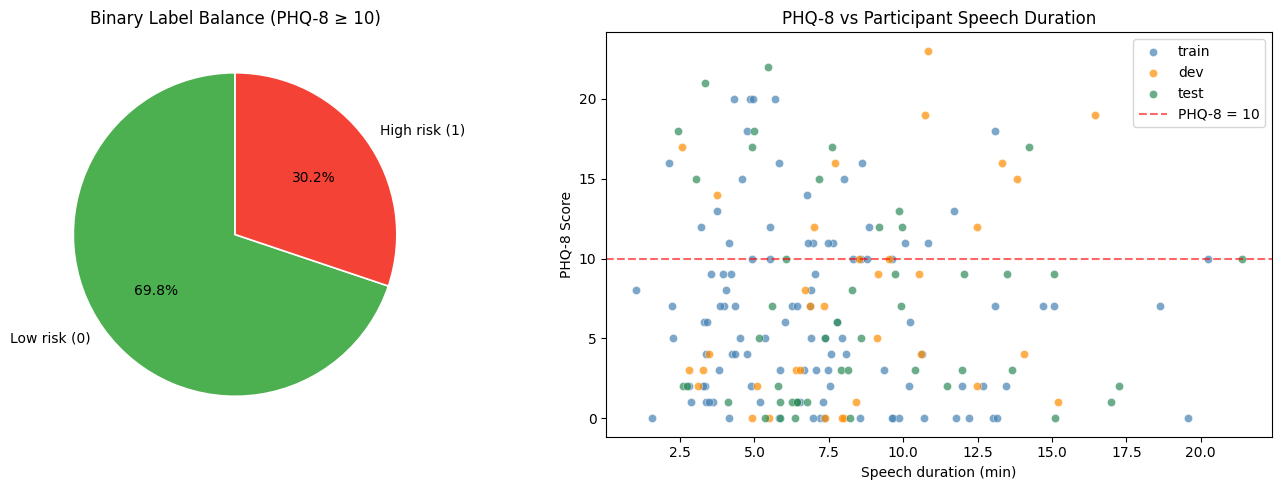

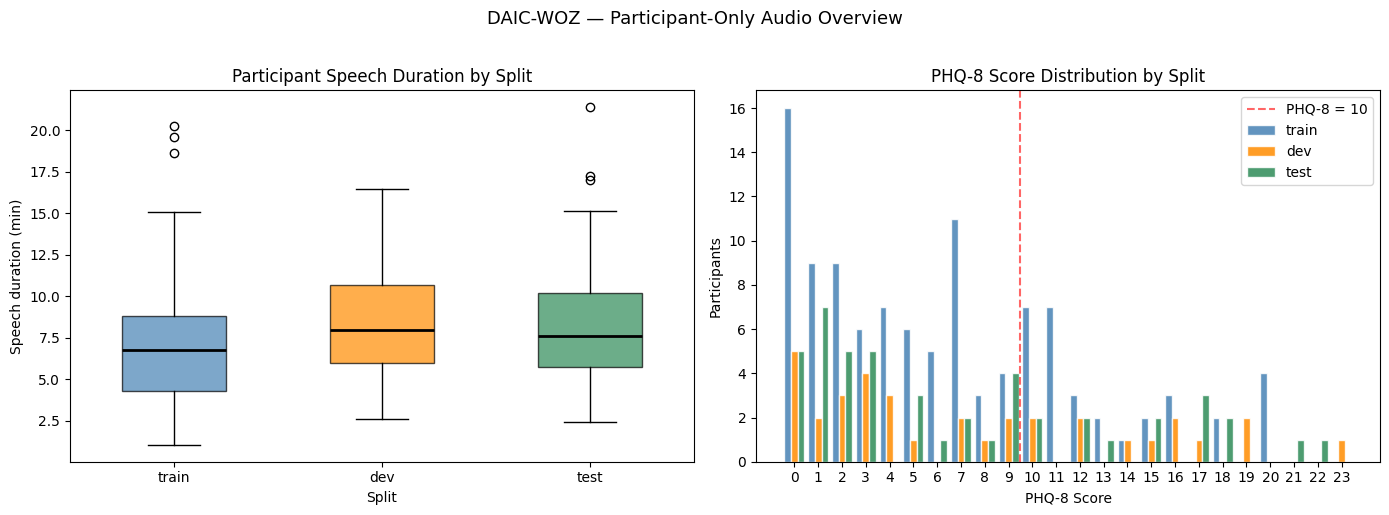

      phq_score                                        participant_dur_s  \
          count  mean   std  min  25%  50%   75%   max             count   
split                                                                      
dev        35.0  7.43  6.59  0.0  2.0  5.0  12.0  23.0              35.0   
test       47.0  6.98  6.47  0.0  1.5  5.0  11.0  22.0              47.0   
train     107.0  6.42  5.46  0.0  2.0  6.0  10.0  20.0             107.0   

                                                                
         mean     std     min     25%     50%     75%      max  
split                                                           
dev    500.00  222.54  154.96  356.61  476.22  640.12   987.24  
test   508.66  254.65  146.38  342.58  457.25  611.44  1282.82  
train  430.56  226.21   62.23  256.30  406.88  529.00  1214.89  


In [34]:
labelled_df = metadata_df.dropna(subset=['phq_score'])

per_participant = labelled_df.groupby('participant_id').agg(
    n_segments        =('segment_idx',       'count'),
    phq_score         =('phq_score',         'first'),
    binary_label      =('binary_label',      'first'),
    split             =('split',             'first'),
    participant_dur_s =('participant_dur_s',  'first'),
    n_turns           =('n_turns',           'first'),
).reset_index()

split_colors = {'train': 'steelblue', 'dev': 'darkorange', 'test': 'seagreen'}
splits_ordered = ['train', 'dev', 'test']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary label balance (pie)
counts = per_participant['binary_label'].value_counts().sort_index()
labels = ['Low risk (0)', 'High risk (1)']
axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[0].set_title(f'Binary Label Balance (PHQ-8 ≥ {PHQ8_THRESHOLD})', fontsize=12)

# PHQ-8 vs speech duration scatter
for split in splits_ordered:
    grp = per_participant[per_participant['split'] == split]
    axes[1].scatter(grp['participant_dur_s'] / 60, grp['phq_score'],
                    alpha=0.7, label=split, color=split_colors[split], s=35, edgecolors='white', linewidths=0.4)
axes[1].axhline(PHQ8_THRESHOLD, color='red', linestyle='--', alpha=0.6, label=f'PHQ-8 = {PHQ8_THRESHOLD}')
axes[1].set_title('PHQ-8 vs Participant Speech Duration', fontsize=12)
axes[1].set_xlabel('Speech duration (min)')
axes[1].set_ylabel('PHQ-8 Score')
axes[1].legend()

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Speech duration by split (box plot)
dur_data  = [per_participant[per_participant['split'] == s]['participant_dur_s'].values / 60
             for s in splits_ordered]
bp = axes2[0].boxplot(dur_data, labels=splits_ordered, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2))
for patch, split in zip(bp['boxes'], splits_ordered):
    patch.set_facecolor(split_colors[split])
    patch.set_alpha(0.7)
axes2[0].set_title('Participant Speech Duration by Split', fontsize=12)
axes2[0].set_xlabel('Split')
axes2[0].set_ylabel('Speech duration (min)')

# PHQ-8 score distribution — one histogram per split, side by side
all_scores = per_participant['phq_score']
bins = range(int(all_scores.min()), int(all_scores.max()) + 2)
bar_width = 0.28
x = list(range(int(all_scores.min()), int(all_scores.max()) + 1))
offsets = [-bar_width, 0, bar_width]
for i, split in enumerate(splits_ordered):
    grp = per_participant[per_participant['split'] == split]
    counts_phq = grp['phq_score'].value_counts().reindex(x, fill_value=0)
    axes2[1].bar([v + offsets[i] for v in x], counts_phq.values,
                 width=bar_width, label=split, color=split_colors[split],
                 alpha=0.85, edgecolor='white')
axes2[1].axvline(PHQ8_THRESHOLD - 0.5, color='red', linestyle='--', alpha=0.6, label=f'PHQ-8 = {PHQ8_THRESHOLD}')
axes2[1].set_title('PHQ-8 Score Distribution by Split', fontsize=12)
axes2[1].set_xlabel('PHQ-8 Score')
axes2[1].set_ylabel('Participants')
axes2[1].legend()
axes2[1].set_xticks(x)

plt.suptitle('DAIC-WOZ — Participant-Only Audio Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(per_participant.groupby('split')[['phq_score', 'participant_dur_s']].describe().round(2))


## Sanity-Check: Load a Saved Spectrogram

Participant 374 | Segment 155
  Shape          : (128, 801)  (n_mels × time_frames)
  dtype          : float32
  Value range    : [-1.5, 2.8] dB
  PHQ-8          : 2  |  Low risk  |  split: train
  Speech duration: 760.88s  |  Turns: 268


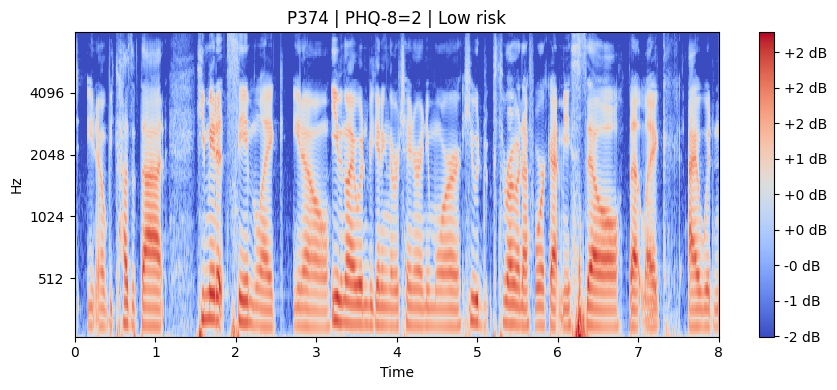


Round-trip check passed.


In [35]:
if len(metadata_rows) > 0:
    sample_row = metadata_df.sample(1).iloc[0]
    loaded     = np.load(sample_row['spectrogram_path'])

    phq_str  = f"{sample_row['phq_score']:.0f}" if pd.notna(sample_row['phq_score']) else 'N/A'
    risk_str = ('High risk' if sample_row['binary_label'] == 1
                else 'Low risk' if sample_row['binary_label'] == 0
                else 'unlabelled')

    print(f'Participant {int(sample_row["participant_id"])} | Segment {int(sample_row["segment_idx"])}')
    print(f'  Shape          : {loaded.shape}  (n_mels × time_frames)')
    print(f'  dtype          : {loaded.dtype}')
    print(f'  Value range    : [{loaded.min():.1f}, {loaded.max():.1f}] dB')
    print(f'  PHQ-8          : {phq_str}  |  {risk_str}  |  split: {sample_row["split"]}')
    print(f'  Speech duration: {sample_row["participant_dur_s"]}s  |  Turns: {sample_row["n_turns"]}')

    fig, ax = plt.subplots(figsize=(9, 4))
    librosa.display.specshow(loaded, sr=TARGET_SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX, ax=ax)
    ax.set_title(f'P{int(sample_row["participant_id"])} | PHQ-8={phq_str} | {risk_str}')
    plt.colorbar(ax.collections[0], ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    print('\nRound-trip check passed.')
else:
    print('[WARN] No segments processed. Check DATASET_DIR.')

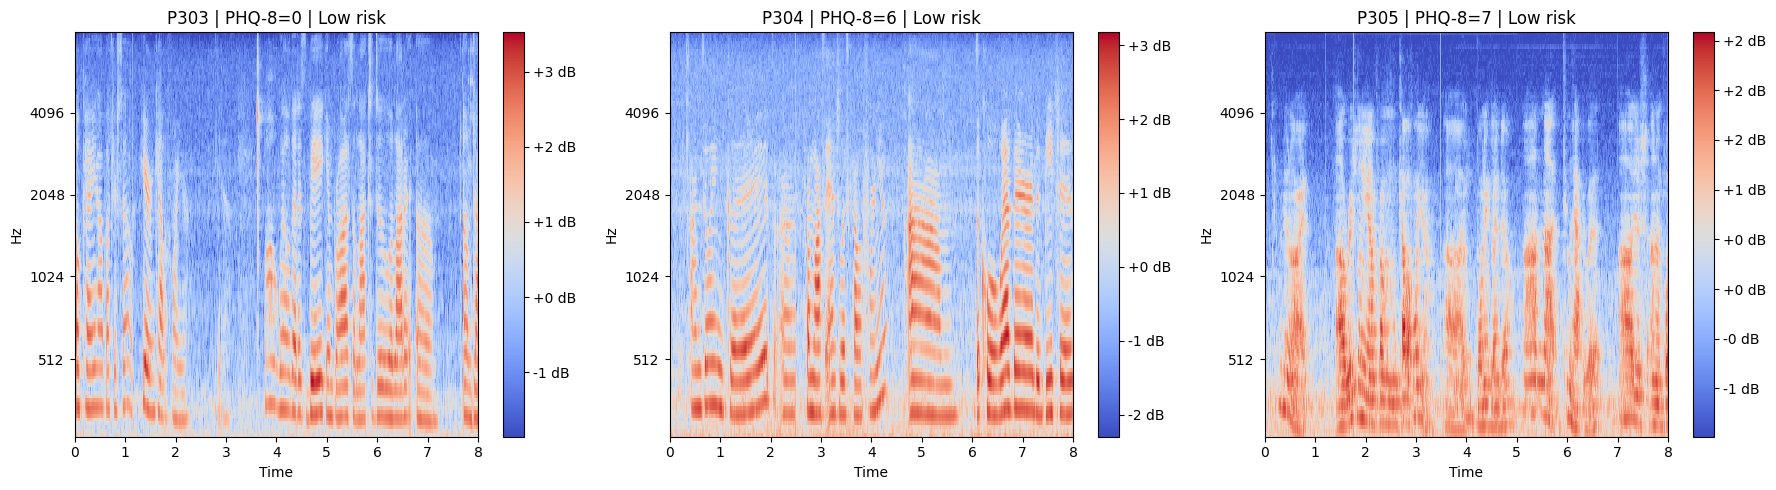

In [36]:
# plot the first 3 samples of loaded spectrograms from train 
train_samples = per_participant[per_participant['split'] == 'train'].head(3)
if train_samples.empty:
    print('[WARN] No training samples found in metadata.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (_, row) in enumerate(train_samples.iterrows()):
        spect_path = SPEC_DIR / row['split'] / f"{row['participant_id']}_seg0000.npy"
        if spect_path.exists():
            spect = np.load(spect_path)
            img = librosa.display.specshow(spect, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                           x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX, ax=axes[i])
            axes[i].set_title(f'P{int(row["participant_id"])} | PHQ-8={row["phq_score"]:.0f} | {"High risk" if row["binary_label"] == 1 else "Low risk"}')
            fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
        else:
            axes[i].text(0.5, 0.5, 'Spectrogram not found', ha='center', va='center')
            axes[i].set_title(f'P{int(row["participant_id"])} | Spectrogram missing')
    plt.tight_layout()
    plt.show()
    